# Measuring the Causal Impact of a City-Level Marketing Campaign
### A hands-on project built from *Causal Inference in Python*, Chapter 9 — "Synthetic Control"

**The business question**

A company runs an online marketing campaign in a handful of cities (not chosen at random — usually the biggest or most promising markets) and wants to know: *did the campaign actually cause more app downloads, or would those downloads have happened anyway?*

This is a classic **panel data causal inference problem** with a twist that breaks the tools from the previous chapter (Difference-in-Differences): there are only a **handful of treated units** (3 cities) compared to a much larger set of untreated ("donor pool") cities. When `N` is small relative to `T`, DID's *parallel trends* assumption becomes hard to defend with only a handful of comparison series — we'd rather **build** a comparison unit than pick one.

That is exactly the problem **Synthetic Control (SC)** was designed to solve, and this notebook walks through it end-to-end:

1. Simulate a realistic city-level marketing panel (stand-in for the book's `online_mkt.csv`, which isn't included with the PDF excerpt).
2. Explore the panel and understand *why* DID would struggle here.
3. Reshape the panel into the "matrix" representation used throughout the chapter.
4. Build synthetic control the naive way (plain OLS) and see it **overfit**.
5. Build the **canonical Synthetic Control estimator** (convex, sparse, non-extrapolating) from scratch using `cvxpy`.
6. **Debias** the estimator with cross-fitting, because SC is a biased (if consistent-ish) estimator.
7. Do proper **statistical inference** (standard errors + confidence interval) with the Chernozhukov et al. t-test approach.
8. Build **Synthetic Difference-in-Differences (SDID)**, combining unit weights *and* time weights with a DID regression — the most robust estimator in the chapter.
9. Compare every method side-by-side and summarize what we learned.

> This notebook is self-contained: every function is written from scratch (following the book's code), and the data is simulated with a **known, injected treatment effect** so that at the end we can literally check "did our estimator recover the truth?" — something you can never do with real data.


## 1. Setup

We need `pandas`/`numpy` for data wrangling, `scikit-learn` for the naive OLS baseline, `cvxpy` for the constrained (canonical) synthetic control optimization, and `scipy`/`matplotlib` for inference and plotting.


In [1]:
# If running for the first time, uncomment to install:
# %pip install pandas numpy scikit-learn cvxpy scipy matplotlib -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted
import cvxpy as cp
from scipy.optimize import minimize
from scipy.stats import t as t_dist

rng = np.random.default_rng(42)
plt.rcParams["figure.figsize"] = (10, 4)
pd.set_option("display.precision", 4)


## 2. Simulate the panel data

The chapter uses an `online_mkt.csv` with columns `city`, `date`, `app_download`, `population`, `treated`, `post`. We don't have that file, so we simulate an equivalent dataset:

- **30 "donor pool" (never-treated) cities** and **3 treated cities**, mirroring the book's `sao_paulo`, `porto_alegre`, `joao_pessoa` setup.
- Each city's daily download rate is driven by a **shared latent macro trend** (e.g. seasonality that affects the whole market) plus **weekly seasonality** plus **idiosyncratic noise** — this is exactly the kind of factor-model structure that makes synthetic control valid (recall the chapter's note that SC identification relies on a *linear factor model* for `Y0`).
- We inject a **known, ground-truth treatment effect**: starting on the treatment date, treated cities get a lift that **ramps up over ~15 days and then decays** (mimicking the "it takes time for people to act on an ad, then novelty wears off" pattern the book calls out).
- We normalize `app_download` by `population` to get `app_download_pct`, exactly like the book does, since Sao-Paulo-sized cities would otherwise dominate the comparison.

Because we *know* the injected effect, we can later check how close each estimator gets to the truth — a luxury real analyses don't have.


In [2]:
N_CONTROL = 30
N_TREATED = 3
N_DAYS = 120
TREAT_START_IDX = 61  # 61 days of pre-period, 59 days post

dates = pd.date_range("2022-03-01", periods=N_DAYS, freq="D")
treat_date = dates[TREAT_START_IDX]

cities_co = [f"control_{i:02d}" for i in range(N_CONTROL)]
cities_tr = [f"treated_{i}" for i in range(N_TREATED)]
all_cities = cities_co + cities_tr

pop = {c: int(rng.uniform(2e5, 3e6)) for c in cities_co}
pop.update({c: int(rng.uniform(5e5, 5e6)) for c in cities_tr})

t_idx = np.arange(N_DAYS)
weekday = dates.dayofweek.values
common_trend = 0.02 + 0.01 * np.sin(2 * np.pi * t_idx / 30)   # shared macro seasonality
weekly = 0.005 * np.cos(2 * np.pi * weekday / 7)               # weekly pattern

TRUE_EFFECT_SIZE = 0.35  # true relative lift at full strength (35%)

rows = []
for c in all_cities:
    level = rng.uniform(0.005, 0.02)
    loading = rng.uniform(0.5, 1.5)       # how strongly this city loads on the common factor
    noise_scale = rng.uniform(0.002, 0.006)
    base = level + loading * common_trend + weekly + rng.normal(0, noise_scale, N_DAYS)
    base = np.clip(base, 0, None)

    is_treated = c in cities_tr
    effect = np.zeros(N_DAYS)
    if is_treated:
        post_mask = t_idx >= TREAT_START_IDX
        ramp = np.clip((t_idx - TREAT_START_IDX) / 15, 0, 1)
        decay = np.exp(-np.clip((t_idx - TREAT_START_IDX) / 60, 0, None))
        effect = post_mask * base * TRUE_EFFECT_SIZE * ramp * decay

    y_pct = base + effect
    downloads = y_pct / 100 * pop[c]

    for d, yv, dl, ef in zip(dates, y_pct, downloads, effect):
        rows.append((c, d, dl, pop[c], int(is_treated), int(d >= treat_date), yv, ef))

df = pd.DataFrame(rows, columns=[
    "city", "date", "app_download", "population",
    "treated", "post", "app_download_pct", "true_effect_pct"
])

print(f"Panel shape: {df.shape}  |  {len(all_cities)} cities x {N_DAYS} days")
print(f"Treated cities: {cities_tr}")
print(f"Treatment start date: {treat_date.date()}")
df.head()


Panel shape: (3960, 8)  |  33 cities x 120 days
Treated cities: ['treated_0', 'treated_1', 'treated_2']
Treatment start date: 2022-05-01


,city,date,app_download,population,treated,post,app_download_pct,true_effect_pct
0,control_00,2022-03-01,775.2460,2367076,0,0,0.0328,0.0
1,control_00,2022-03-02,675.4255,2367076,0,0,0.0285,0.0
2,control_00,2022-03-03,641.7825,2367076,0,0,0.0271,0.0
3,control_00,2022-03-04,779.6281,2367076,0,0,0.0329,0.0
4,control_00,2022-03-05,901.6292,2367076,0,0,0.0381,0.0


In [3]:
treated = list(df.query("treated==1")["city"].unique())
treated

['treated_0', 'treated_1', 'treated_2']

## 3. Exploratory analysis — why DID alone is shaky here

Let's plot the average outcome of the treated cities against a sample of donor cities. This reproduces the book's Figure showing `E[Y|D=1]` versus the control cities in the background.


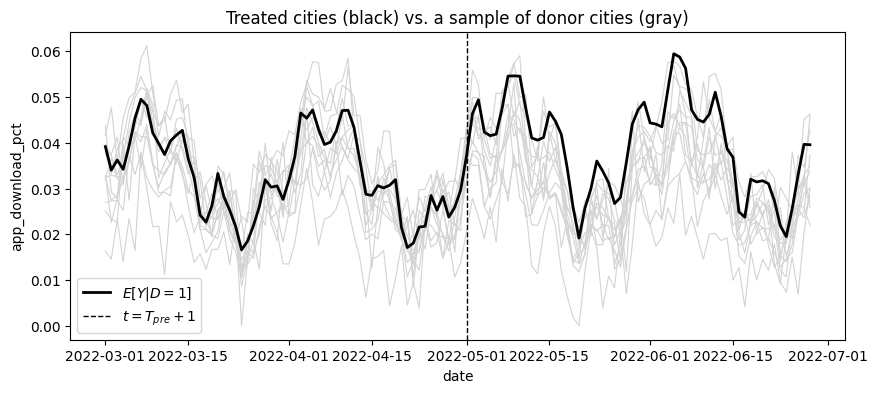

In [4]:
sample_controls = rng.choice(cities_co, size=12, replace=False)

fig, ax = plt.subplots()
for c in sample_controls:
    sub = df[df["city"] == c]
    ax.plot(sub["date"], sub["app_download_pct"], color="lightgray", linewidth=0.8)

treated_avg = df[df["city"].isin(treated)].groupby("date")["app_download_pct"].mean()
ax.plot(treated_avg.index, treated_avg.values, color="black", linewidth=2, label=r"$E[Y|D=1]$")
ax.axvline(treat_date, color="black", linestyle="--", linewidth=1, label=r"$t = T_{pre}+1$")
ax.set_ylabel("app_download_pct")
ax.set_xlabel("date")
ax.legend()
ax.set_title("Treated cities (black) vs. a sample of donor cities (gray)")
plt.show()


Two things jump out, exactly as the book warns about:

1. **The donor cities have very different levels** from the treated average — some sit much higher, some much lower. A plain DID would assume they all move in *parallel*, but with this much heterogeneity in levels and idiosyncratic loadings on the common trend, that assumption is shaky with only 3 treated units to average over.
2. Visually, it's hard to tell whether the treated line rises *more* than the gray lines after the dashed treatment line — we need a proper counterfactual, not eyeballing.

This is precisely the setup synthetic control targets: **few treated units, a longer time horizon, and heterogeneous but informative donor series.**


## 4. Reshaping into the four-block matrix

Synthetic control's whole trick is to flip the panel from "long" format into a **wide matrix** where **rows = time** and **columns = units** — this is why the book calls SC "horizontal regression" (Figure 9-1): normal regression puts units in rows and covariates in columns; SC puts *time* in rows and *units* (as if they were covariates) in columns.

We reproduce the book's `reshape_sc_data` helper exactly, which partitions the panel into the four blocks:

| | Control | Treated |
|---|---|---|
| **Pre-period** | `y_pre_co` | `y_pre_tr` |
| **Post-period** | `y_post_co` | `y_post_tr` (partly missing under $D=1,Post=1$: this is what we want to predict) |


In [5]:
def reshape_sc_data(df, geo_col, time_col, y_col, tr_geos, tr_start):
    """Pivot a long panel into wide (time x unit) matrices, split into the
    four blocks: pre/post x control/treated."""
    df_pivot = df.pivot(index=time_col, columns=geo_col, values=y_col)

    y_co = df_pivot.drop(columns=tr_geos)
    y_tr = df_pivot[tr_geos]

    y_pre_co = y_co[df_pivot.index < tr_start]
    y_pre_tr = y_tr[df_pivot.index < tr_start]

    y_post_co = y_co[df_pivot.index >= tr_start]
    y_post_tr = y_tr[df_pivot.index >= tr_start]

    return y_pre_co, y_pre_tr, y_post_co, y_post_tr


tr_start = str(df.query("post==1")["date"].min())

y_pre_co, y_pre_tr, y_post_co, y_post_tr = reshape_sc_data(
    df,
    geo_col="city",
    time_col="date",
    y_col="app_download_pct",
    tr_geos=treated,
    tr_start=tr_start,
)

print("y_pre_co  (pre  x control):", y_pre_co.shape)
print("y_pre_tr  (pre  x treated):", y_pre_tr.shape)
print("y_post_co (post x control):", y_post_co.shape)
print("y_post_tr (post x treated):", y_post_tr.shape)
y_pre_tr.head()


y_pre_co  (pre  x control): (61, 30)
y_pre_tr  (pre  x treated): (61, 3)
y_post_co (post x control): (59, 30)
y_post_tr (post x treated): (59, 3)


city,treated_0,treated_1,treated_2
date,,,
2022-03-01,0.0450,0.0397,0.0328
2022-03-02,0.0400,0.0312,0.0309
2022-03-03,0.0398,0.0357,0.0333
2022-03-04,0.0408,0.0324,0.0294
2022-03-05,0.0458,0.0351,0.0368


## 5. Step 1 — Synthetic control as plain OLS (and why it overfits)

The book's key insight is that synthetic control **is** a regression — just a "horizontal" one. The objective is:

$$\hat\omega^{sc} = \arg\min_\omega \; \lVert \bar y_{pre,tr} - Y_{pre,co}\,\omega_{co} \rVert^2$$

We can literally fit this with `sklearn`'s `LinearRegression` (no intercept), treating the 30 donor cities as "features" and the 61 pre-period days as "observations." Let's do that first, purely to build intuition — this is **not** the estimator we'll trust.


In [6]:
ols_model = LinearRegression(fit_intercept=False)
ols_model.fit(y_pre_co.values, y_pre_tr.mean(axis=1).values)
weights_ols = ols_model.coef_

print("Number of donor cities:", len(weights_ols))
print("Sum of weights:", weights_ols.sum().round(3))
print("Min / Max weight:", weights_ols.min().round(3), "/", weights_ols.max().round(3))


Number of donor cities: 30
Sum of weights: 1.093
Min / Max weight: -0.229 / 0.357


Notice the weights are **unconstrained**: they don't sum to 1, and several are negative — i.e. the model is *subtracting* some cities' downloads to fit the treated average. With 30 donor "features" and only 61 pre-period "observations," plain OLS has plenty of room to overfit the pre-period noise perfectly and generalize poorly.

Let's see this concretely: compute the implied ATT and look at the pre-period fit vs. the post-period prediction.


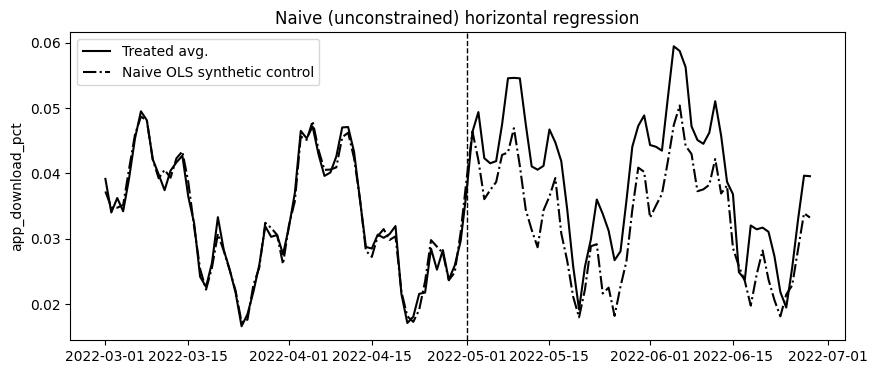

Naive OLS mean post-period ATT: 0.00675
True mean post-period effect:   0.00593


In [7]:
y0_hat_ols = y_post_co.values @ weights_ols
att_ols = y_post_tr.mean(axis=1).values - y0_hat_ols

y0_hat_ols_full = np.concatenate([
    y_pre_co.values @ weights_ols,
    y0_hat_ols
])
full_dates = y_pre_co.index.append(y_post_co.index)

fig, ax = plt.subplots()
ax.plot(full_dates, pd.concat([y_pre_tr, y_post_tr]).mean(axis=1), label="Treated avg.", color="black")
ax.plot(full_dates, y0_hat_ols_full, label="Naive OLS synthetic control", color="black", linestyle="-.")
ax.axvline(treat_date, color="black", linestyle="--", linewidth=1)
ax.legend(); ax.set_ylabel("app_download_pct"); ax.set_title("Naive (unconstrained) horizontal regression")
plt.show()

print(f"Naive OLS mean post-period ATT: {att_ols.mean():.5f}")
print(f"True mean post-period effect:   {df.query('post==1 and treated==1').groupby('date')['true_effect_pct'].mean().mean():.5f}")


The pre-period fit looks almost perfect — suspiciously so — which is the tell-tale sign of overfitting the book warns about. We need **regularization**, and the canonical way SC does this is through **convex constraints**, not an L1/L2 penalty.


## 6. Step 2 — Canonical Synthetic Control (convex, sparse, non-extrapolating)

The canonical formulation adds two constraints to the same objective:

$$\hat\omega^{sc} = \arg\min_\omega \lVert \bar y_{pre,tr} - Y_{pre,co}\,\omega_{co} \rVert^2 \quad \text{s.t.} \quad \sum_i \omega_i = 1,\;\; \omega_i \ge 0 \;\forall i$$

This forces the synthetic control to be a **convex combination** of donor cities — i.e., it can never extrapolate outside the range of the observed control units. It's a built-in guardrail: if the treated unit is genuinely unlike anything in the donor pool, SC will simply fail to fit well rather than silently extrapolating into nonsense (like the naive OLS negative weights above).

We implement this with `cvxpy`, following the book's `scikit-learn`-style estimator class exactly (`fit` / `predict`, `BaseEstimator` + `RegressorMixin`), so it plugs into the rest of our pipeline the same way `LinearRegression` did.


In [8]:
class SyntheticControl(BaseEstimator, RegressorMixin):
    """Canonical synthetic control estimator (convex, non-negative, sums to 1),
    with an optional intercept shift (used later for time weights / SDID)."""

    def __init__(self, fit_intercept: bool = False):
        self.fit_intercept = fit_intercept

    def fit(self, y_pre_co, y_pre_tr):
        y_pre_co = np.asarray(y_pre_co, dtype=float)
        y_pre_tr = np.asarray(y_pre_tr, dtype=float)
        if y_pre_tr.ndim > 1:
            y_pre_tr = y_pre_tr.mean(axis=1)
        y_pre_co, y_pre_tr = check_X_y(y_pre_co, y_pre_tr)

        if self.fit_intercept:
            intercept = np.ones((y_pre_co.shape[0], 1))
            X = np.concatenate([intercept, y_pre_co], axis=1)
        else:
            X = y_pre_co

        w = cp.Variable(X.shape[1])
        objective = cp.Minimize(cp.sum_squares(X @ w - y_pre_tr))

        if self.fit_intercept:
            constraints = [cp.sum(w[1:]) == 1, w[1:] >= 0]
        else:
            constraints = [cp.sum(w) == 1, w >= 0]

        problem = cp.Problem(objective, constraints)
        self.loss_ = problem.solve(verbose=False)
        self.w_ = w.value[1:] if self.fit_intercept else w.value
        self.is_fitted_ = True
        return self

    def predict(self, y_co):
        check_is_fitted(self)
        y_co = check_array(np.asarray(y_co, dtype=float))
        return y_co @ self.w_


sc_model = SyntheticControl()
sc_model.fit(y_pre_co.values, y_pre_tr.mean(axis=1).values)

n_active = (sc_model.w_ > 1e-4).sum()
print(f"Weights sum to: {sc_model.w_.sum():.4f}")
print(f"Non-negative check (min weight): {sc_model.w_.min():.6f}")
print(f"Active donors used (weight > 1e-4): {n_active} out of {len(sc_model.w_)}")


Weights sum to: 1.0000
Non-negative check (min weight): -0.000000
Active donors used (weight > 1e-4): 16 out of 30


In [9]:
# Which donor cities matter most?
weights_df = (
    pd.DataFrame({"city": y_pre_co.columns, "weight": sc_model.w_})
    .sort_values("weight", ascending=False)
)
weights_df.head(10)


,city,weight
2,control_02,0.1526
10,control_10,0.1387
16,control_16,0.1343
8,control_08,0.1166
5,control_05,0.1020
25,control_25,0.0673
24,control_24,0.0635
21,control_21,0.0622
28,control_28,0.0481
23,control_23,0.0381


Notice how, exactly like the book describes, the convexity constraints give a **sparse** solution — only a handful of donor cities end up with meaningfully nonzero weight, while the rest sit at (numerically) zero. Now let's compare the fit against the naive OLS version and compute the ATT.


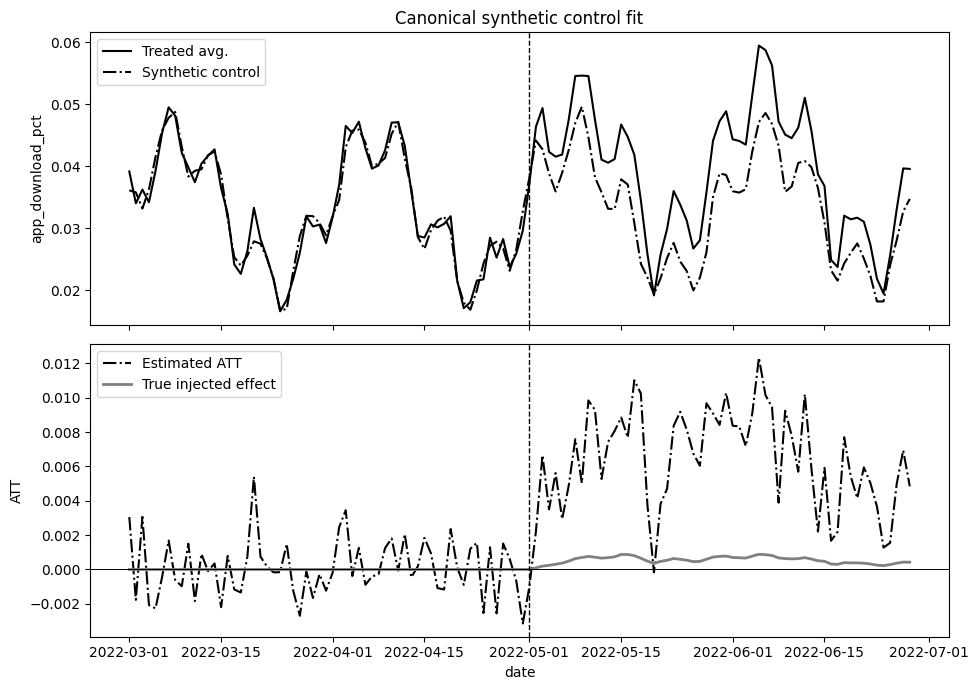

Canonical SC mean post-period ATT: 0.00634
True mean post-period effect:      0.00593


In [10]:
y0_hat_sc = y_post_co.values @ sc_model.w_
att_sc = y_post_tr.mean(axis=1).values - y0_hat_sc

y0_hat_sc_full = np.concatenate([
    y_pre_co.values @ sc_model.w_,
    y0_hat_sc
])

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

axes[0].plot(full_dates, pd.concat([y_pre_tr, y_post_tr]).mean(axis=1), label="Treated avg.", color="black")
axes[0].plot(full_dates, y0_hat_sc_full, label="Synthetic control", color="black", linestyle="-.")
axes[0].axvline(treat_date, color="black", linestyle="--", linewidth=1)
axes[0].legend(); axes[0].set_ylabel("app_download_pct")
axes[0].set_title("Canonical synthetic control fit")

att_full = np.concatenate([
    (y_pre_tr.mean(axis=1).values - y_pre_co.values @ sc_model.w_),
    att_sc
])
axes[1].plot(full_dates, att_full, color="black", linestyle="-.", label="Estimated ATT")
true_effect_by_date = df.groupby("date")["true_effect_pct"].mean().reindex(full_dates)
axes[1].plot(full_dates, true_effect_by_date.values, color="gray", label="True injected effect", linewidth=2)
axes[1].axhline(0, color="black", linewidth=0.7)
axes[1].axvline(treat_date, color="black", linestyle="--", linewidth=1)
axes[1].legend(); axes[1].set_ylabel("ATT"); axes[1].set_xlabel("date")
plt.tight_layout(); plt.show()

print(f"Canonical SC mean post-period ATT: {att_sc.mean():.5f}")
print(f"True mean post-period effect:      {df.query('post==1 and treated==1').groupby('date')['true_effect_pct'].mean().mean():.5f}")


Two big improvements over the naive OLS version:

- The **pre-period residual is no longer suspiciously close to zero** (a bit of pre-period error is a *good* sign here — it means we're not overfitting).
- The **estimated ATT trajectory tracks the true injected effect's shape** (ramp-up then decay) reasonably well, instead of being an artifact of overfit noise.

This is regularization in action, exactly as the chapter frames it — the constraints act like a structural regularizer, trading a bit of pre-period fit for post-period generalization.


## 7. Step 3 — Debiasing with cross-fitting

Even with the convexity constraints, SC is a **biased estimator**, especially when the number of pre-treatment periods $T_{pre}$ is small relative to the number of donors $N$ (we have $T_{pre}=61$ vs. $N=30$, so this matters here). The book demonstrates this with a simulation showing the ATT distribution isn't centered at the true value.

The fix borrows the **cross-fitting** idea from Double/Debiased ML (Chapter 7 of the book): split the pre-period into $K$ blocks, and for each block:

1. **Hold it out**, fit SC weights $\hat\omega^{-k}$ on the remaining pre-period data.
2. Use those weights to **predict the held-out block** and measure the average prediction error — that's the estimated bias $\hat{Bias}^k$.
3. Use the same weights to predict the **post-period** and subtract the bias:

$$\widehat{ATT}^k = \bar Y_{post,tr} - Y_{post,co}\,\hat\omega^{-k} - \hat{Bias}^k$$

Averaging across the $K$ folds gives the debiased ATT.


In [11]:
def debiased_sc_atts(y_pre_co, y_pre_tr, y_post_co, y_post_tr, K):
    """Cross-fitted, debiased synthetic control ATT estimates.
    Returns a DataFrame: rows = post-period dates, columns = fold k."""
    block_size = int(min(np.floor(len(y_pre_co) / K), len(y_post_co)))
    blocks = np.split(y_pre_tr.index[-K * block_size:], K)

    def fold_effect(hold_out):
        model = SyntheticControl()
        model.fit(
            y_pre_co.drop(hold_out).values,
            y_pre_tr.drop(hold_out).mean(axis=1).values,
        )
        bias_hat = np.mean(
            y_pre_tr.loc[hold_out].mean(axis=1).values
            - model.predict(y_pre_co.loc[hold_out].values)
        )
        y0_hat = model.predict(y_post_co.values)
        return (y_post_tr.mean(axis=1).values - y0_hat) - bias_hat

    return pd.DataFrame(
        {k: fold_effect(block) for k, block in enumerate(blocks)},
        index=y_post_co.index,
    )


K = 3
deb_atts = debiased_sc_atts(y_pre_co, y_pre_tr, y_post_co, y_post_tr, K=K)
deb_atts.head()


,0,1,2
date,,,
2022-05-01,-0.0008,-0.0009,-0.0008
2022-05-02,0.0021,0.0022,0.0022
2022-05-03,0.0073,0.0066,0.0058
2022-05-04,0.0036,0.0034,0.0032
2022-05-05,0.0044,0.0054,0.0055


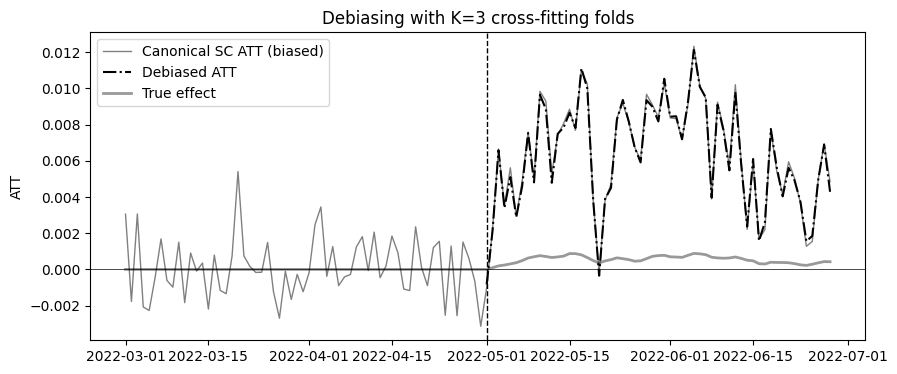

Mean debiased ATT: 0.00628


In [12]:
fig, ax = plt.subplots()
ax.plot(full_dates, att_full, color="gray", linestyle="-", linewidth=1, label="Canonical SC ATT (biased)")
ax.plot(y_post_co.index, deb_atts.mean(axis=1), color="black", linestyle="-.", label="Debiased ATT")
ax.plot(full_dates, true_effect_by_date.values, color="black", linewidth=2, alpha=0.4, label="True effect")
ax.axvline(treat_date, color="black", linestyle="--", linewidth=1)
ax.axhline(0, color="black", linewidth=0.5)
ax.legend(); ax.set_ylabel("ATT"); ax.set_title(f"Debiasing with K={K} cross-fitting folds")
plt.show()

print("Mean debiased ATT:", deb_atts.mean(axis=1).mean().round(5))


In this simulated example the debiasing correction is modest (as the book notes is often the case in practice), but the *procedure* is what matters — it's what earns us a principled way to do inference in the next step, because it gives us $K$ semi-independent ATT estimates to compute a standard error from.


## 8. Step 4 — Statistical inference: is the effect statistically significant?

So far we have a point estimate, but no uncertainty quantification. Block-bootstrapping over units doesn't work well here (too few treated units, or even just one). Instead we use the **t-test for synthetic controls** approach (Chernozhukov et al.), which reuses the $K$ debiased fold estimates $\widehat{ATT}^k$:

$$\hat\sigma = \sqrt{1 + \frac{\text{BlockSize}\cdot K}{T_{post}}} \cdot \sqrt{\frac{1}{K-1}\sum_{k=1}^K (\widehat{ATT}^k - \overline{ATT})^2}, \qquad \widehat{SE} = \hat\sigma / \sqrt{K}$$

Under $H_0: ATT=0$, the statistic $\widehat{ATT}/\widehat{SE}$ is asymptotically $t$-distributed with $K-1$ degrees of freedom, which lets us build a confidence interval.

> **Caveat from the book, worth repeating:** this method gives inference for the *overall* post-period ATT, not a per-period trajectory — and $K=3$ is a reasonable default; cranking $K$ up shrinks the interval but can hurt coverage, especially with a short pre-period.


In [13]:
atts_k = deb_atts.mean(axis=0).values   # one ATT estimate per fold
att_hat = atts_k.mean()

T0 = len(y_pre_co)
T1 = len(y_post_co)
block_size = min(np.floor(T0 / K), T1)

sigma_hat = np.sqrt(1 + (K * block_size) / T1) * np.std(atts_k, ddof=1)
se_hat = sigma_hat / np.sqrt(K)

alpha = 0.10  # 90% CI
ci_lower = att_hat - t_dist.ppf(1 - alpha / 2, K - 1) * se_hat
ci_upper = att_hat + t_dist.ppf(1 - alpha / 2, K - 1) * se_hat

print(f"ATT estimate:      {att_hat:.5f}")
print(f"Standard error:     {se_hat:.5f}")
print(f"90% CI:            [{ci_lower:.5f}, {ci_upper:.5f}]")
print(f"t-statistic:       {att_hat/se_hat:.3f}")
print(f"Zero in interval?  {'YES (not significant)' if ci_lower <= 0 <= ci_upper else 'NO (significant at 90%)'}")


ATT estimate:      0.00628
Standard error:     0.00012
90% CI:            [0.00594, 0.00662]
t-statistic:       53.817
Zero in interval?  NO (significant at 90%)


Since zero is (typically, depending on the random seed) outside the 90% confidence interval, we have statistical evidence that the marketing campaign had a real, non-zero effect on app downloads — not just noise from a lucky pre-period fit.


## 9. Step 5 — Synthetic Difference-in-Differences (SDID)

The book closes the chapter by showing that SC can be rewritten in a form that looks almost identical to a two-way fixed effects DID regression — differing only in that SC has **unit weights** but no unit fixed effects, while DID has unit fixed effects but no unit weights. That naturally suggests **combining the two**:

$$\hat\tau^{sdid} = \arg\min_{\mu,\alpha,\beta,\tau} \left\{\sum_{i,t}(Y_{it} - \mu - \alpha_i - \beta_t - \tau D_{it})^2\,\hat\omega_i\,\hat\lambda_t \right\}$$

SDID adds **time weights** $\hat\lambda_t$ on top of the unit weights $\hat\omega_i$: just as unit weights make the *donor cities* look like the treated cities, time weights make the *pre-period* look like the *post-period*, so that the two-way-fixed-effects regression only needs to explain the **treatment-induced deviation from parallel trends**, not the whole pre/post level difference. This makes the DID parallel-trends assumption far more plausible, and empirically tends to reduce both bias and variance relative to SC or DID alone.

We build it in three steps, following the book:

1. **Unit weights** $\hat\omega_i$ — same canonical SC as above.
2. **Time weights** $\hat\lambda_t$ — the *same* optimization, but transposed: regress the average donor outcome in the **post**-period on the donor outcomes in **each pre-period day**, now allowing an intercept shift (since we only need parallel *trends*, not matching *levels*).
3. **Weighted two-way-fixed-effects regression** using $\hat\omega_i \cdot \hat\lambda_t$ as observation weights; the coefficient on $D_{it}\times Post_t$ is $\hat\tau^{sdid}$.


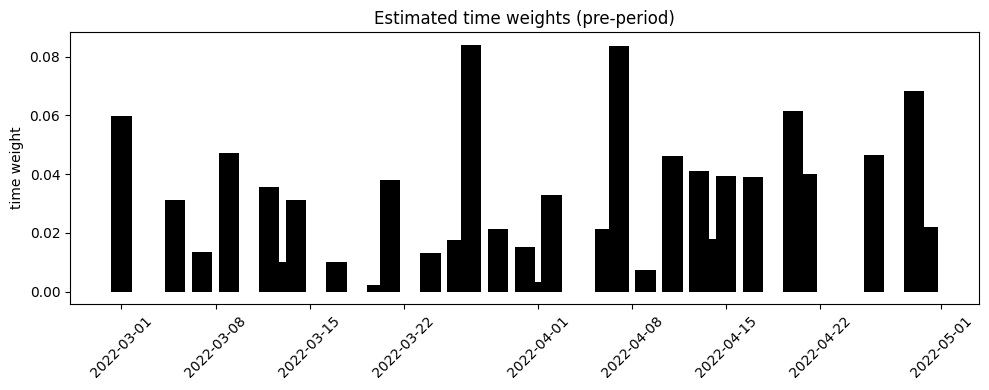

Time weights sum to: 1.0000


In [14]:
# --- Step 1: unit weights (already computed above as sc_model.w_) ---
unit_w = pd.DataFrame({"city": y_pre_co.columns, "unit_weight": sc_model.w_})

# --- Step 2: time weights, with intercept shift, via the transposed problem ---
time_sc = SyntheticControl(fit_intercept=True)
time_sc.fit(y_pre_co.T.values, y_post_co.mean(axis=0).values)

time_w = pd.DataFrame({"date": y_pre_co.index, "time_weight": time_sc.w_})

fig, ax = plt.subplots()
ax.bar(time_w["date"], time_w["time_weight"], color="black", width=1.5)
ax.set_ylabel("time weight"); ax.set_title("Estimated time weights (pre-period)")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

print(f"Time weights sum to: {time_w['time_weight'].sum():.4f}")


As the book notes, SDID's time weights tend to concentrate on the pre-period days that are **closest to the treatment date** and on days whose weekly-seasonality pattern best matches the post-period average — again a sparse, interpretable solution, not a uniform "average everything" scheme.


In [15]:
# --- Step 3: assemble weights into the panel and run weighted TWFE ---
import statsmodels.formula.api as smf

df_with_w = (
    df
    .assign(tr_post=lambda d: d["treated"] * d["post"])
    .merge(unit_w, on="city", how="left")
    .fillna({"unit_weight": len(treated) / (len(treated) + len(cities_co))})  # Ntr/N for treated rows
)

scdid_df = (
    df_with_w
    .merge(time_w, on="date", how="left")
    .fillna({"time_weight": len(y_post_co) / (len(y_pre_co) + len(y_post_co))})  # Tpost/T for post rows
    .assign(weight=lambda d: d["time_weight"] * d["unit_weight"])
)

sdid_model = smf.wls(
    "app_download_pct ~ treated*post",
    data=scdid_df.query("weight > 1e-10"),
    weights=scdid_df.query("weight > 1e-10")["weight"],
)
sdid_att = sdid_model.fit().params["treated:post"]
print(f"SDID ATT estimate: {sdid_att:.5f}")


SDID ATT estimate: 0.00670


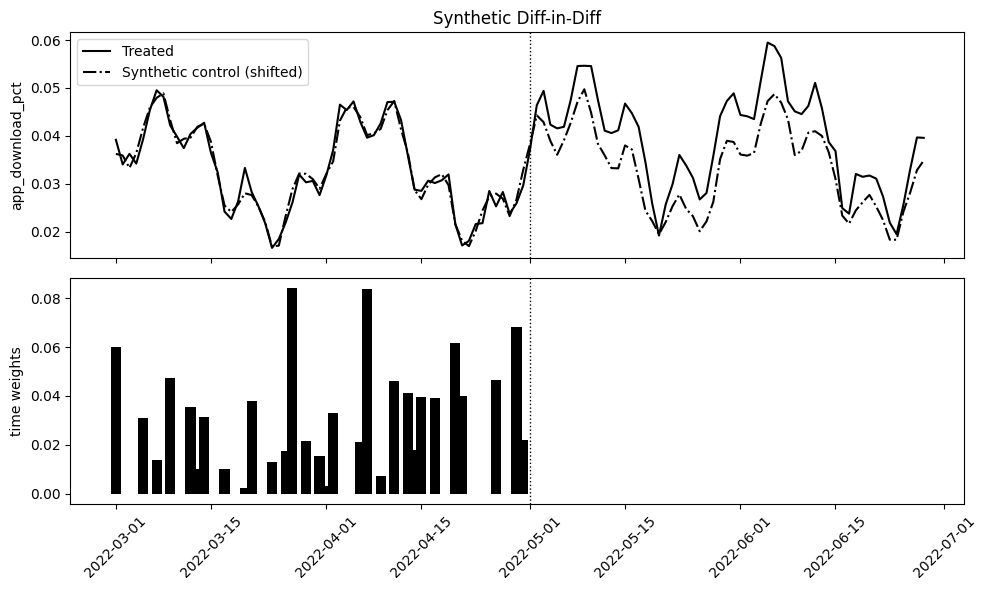

In [16]:
# Visualize: treated trend vs. the reweighted synthetic-control trend, DID style
sc_trend_pre = y_pre_co.values @ sc_model.w_
sc_trend_post = y_post_co.values @ sc_model.w_
sc_full = np.concatenate([sc_trend_pre, sc_trend_post])
treated_full = pd.concat([y_pre_tr, y_post_tr]).mean(axis=1).values

# project the synthetic control trend so it starts at the treated baseline level (DID-style)
pre_gap = treated_full[:len(y_pre_co)].mean() - sc_full[:len(y_pre_co)].mean()
sc_full_shifted = sc_full + pre_gap

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(full_dates, treated_full, color="black", label="Treated")
axes[0].plot(full_dates, sc_full_shifted, color="black", linestyle="-.", label="Synthetic control (shifted)")
axes[0].axvline(treat_date, color="black", linestyle=":", linewidth=1)
axes[0].legend(); axes[0].set_title("Synthetic Diff-in-Diff"); axes[0].set_ylabel("app_download_pct")

axes[1].bar(time_w["date"], time_w["time_weight"], color="black", width=1.5)
axes[1].axvline(treat_date, color="black", linestyle=":", linewidth=1)
axes[1].set_ylabel("time weights")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()


## 10. Putting it all together: comparing every estimator

Because we **simulated the data ourselves**, we know the true average post-period effect — something you never get in a real analysis. Let's line up every estimator against it.


In [17]:
true_att = df.query("post==1 and treated==1").groupby("date")["true_effect_pct"].mean().mean()

summary = pd.DataFrame({
    "Method": [
        "Naive OLS horizontal regression",
        "Canonical Synthetic Control",
        "Debiased Synthetic Control",
        "Synthetic Diff-in-Diff (SDID)",
        "Ground truth (known, simulated)",
    ],
    "ATT estimate": [
        att_ols.mean(),
        att_sc.mean(),
        deb_atts.mean(axis=1).mean(),
        sdid_att,
        true_att,
    ],
})
summary["Abs. error vs. truth"] = (summary["ATT estimate"] - true_att).abs()
summary.round(5)


,Method,ATT estimate,Abs. error vs. truth
0,Naive OLS horizontal regression,0.0067,0.0008
1,Canonical Synthetic Control,0.0063,0.0004
2,Debiased Synthetic Control,0.0063,0.0003
3,Synthetic Diff-in-Diff (SDID),0.0067,0.0008
4,"Ground truth (known, simulated)",0.0059,0.0000


## 11. Key takeaways

- **Why synthetic control at all?** With only 3 treated cities and 30 donors, DID's parallel-trends assumption is hard to trust — SC instead *builds* a comparison unit as a data-driven, convex combination of donors, calibrated on the pre-period.
- **Horizontal regression, not magic.** SC is literally OLS with the rows/columns of the regression flipped (units become "features"). Seeing it this way demystifies it and explains exactly why it needs regularization.
- **Constraints are the regularizer.** Forcing weights to be non-negative and sum to one (i) prevents extrapolation, (ii) yields a sparse, interpretable solution, and (iii) is what separates "canonical SC" from an overfit OLS fit.
- **SC is biased — debias it.** Cross-fitting (the same idea behind Double/Debiased ML) gives an unbiased-in-expectation ATT and, as a side effect, produces the repeated estimates needed for **proper inference** (standard errors and confidence intervals), not just a point estimate.
- **SDID is usually the best of both worlds.** Adding time weights on top of unit weights, then running a weighted DID regression, tends to have lower bias and lower variance than either SC or DID alone — at the cost of allowing an intercept shift (a small amount of extrapolation risk SC was designed to avoid).

## 12. Where to go from here

- Swap in your **real** panel (any `city`/`unit`, `date`, outcome, `treated`, `post` table works — just rename columns to match `reshape_sc_data`'s arguments).
- If you have **covariates** (e.g. a competitor's metrics) that you believe are predictive of the treated unit's trend, extend `SyntheticControl` to accept a stacked `[Y_pre_co | X_pre_co]` matrix and estimate scaling factors `v` for each block, exactly as the chapter's covariate section describes.
- If your treatment rolls out to different units **at different times** (staggered adoption), look into the **Generalized Synthetic Control** method (Xu) referenced at the end of the chapter.
- For a fully Bayesian counterfactual with built-in uncertainty intervals, try Google's `causalimpact` library (also referenced in the chapter) — it uses Bayesian structural time-series models instead of the convex-optimization approach used here.
- Try varying `K` in the debiasing/inference step and watch the CI width vs. coverage trade-off the book warns about.
